<class 'pandas.core.frame.DataFrame'>
Index: 4787 entries, 97 to 11275
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            4787 non-null   object 
 1   production_field  4787 non-null   object 
 2   year              4787 non-null   int64  
 3   value             4787 non-null   float64
 4   region_standard   4787 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 224.4+ KB
None

Missing values by column:
 region              0
production_field    0
year                0
value               0
region_standard     0
dtype: int64

Number of unique regions: 85
Number of unique years: 16
Number of production sectors: 8

Production value statistics:
 count    4.787000e+03
mean     2.206526e+08
std      6.216324e+08
min      1.596780e+04
25%      8.559441e+06
50%      3.788467e+07
75%      1.638414e+08
max      9.969869e+09
Name: value, dtype: float64

Number of duplicates: 0

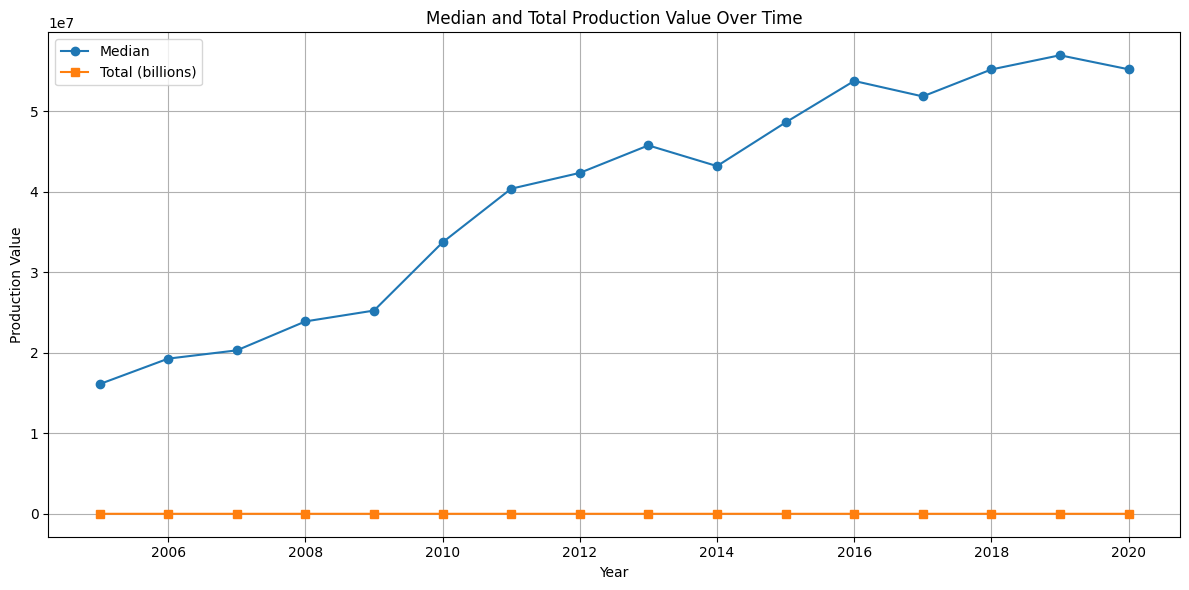

<Figure size 1600x600 with 0 Axes>

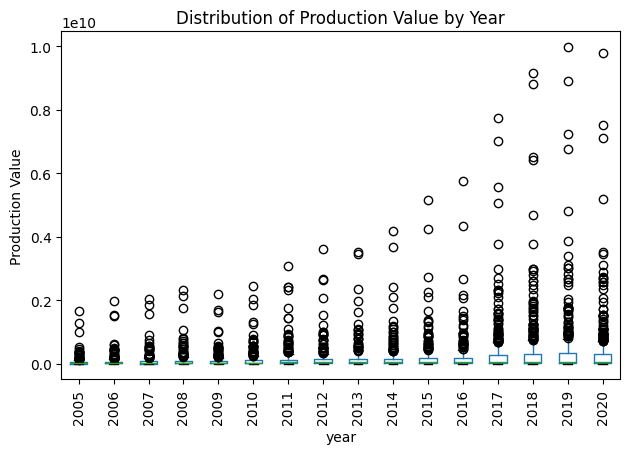

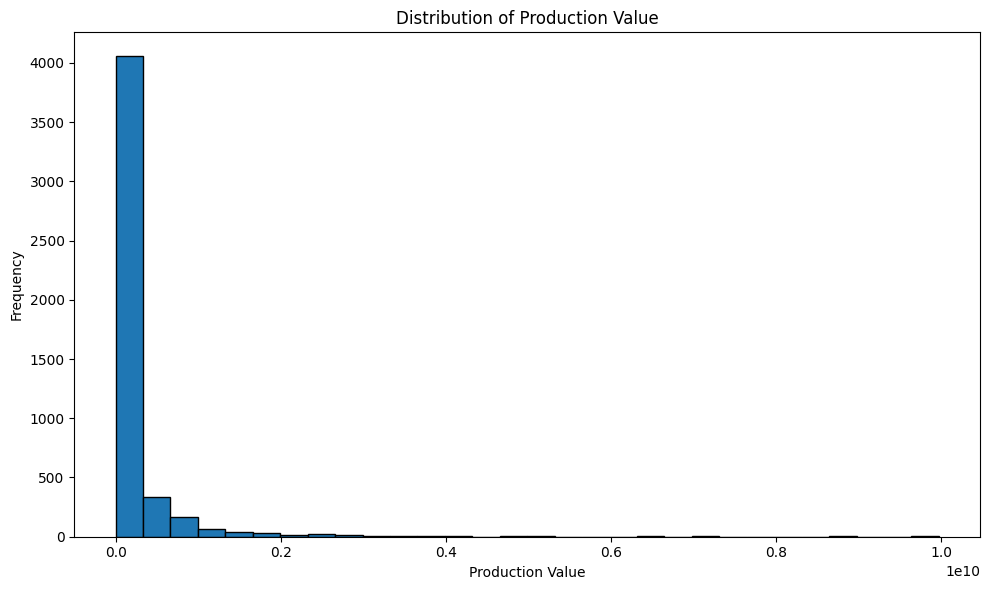

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/regional_production_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Check data quality
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Unique regions, years, and sectors
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())
print("Number of production sectors:", df["production_field"].nunique())

# 5. Summary statistics
print("\nProduction value statistics:\n", df["value"].describe())

# 6. Duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicates:", duplicates)

# 7. Outliers (IQR)
Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["value"] < lower_bound) |
    (df["value"] > upper_bound)
]

print("\nNumber of outliers:", outliers.shape[0])

# 8. Top-5 highest values
top5 = df.sort_values(by="value", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "production_field", "value"]])

# 9. Median and total trends
median_value = df.groupby("year")["value"].median()
total_value = df.groupby("year")["value"].sum()

plt.figure(figsize=(12,6))
plt.plot(median_value.index, median_value.values, marker="o", label="Median")
plt.plot(total_value.index, total_value.values / 1e9, marker="s", label="Total (billions)")
plt.title("Median and Total Production Value Over Time")
plt.xlabel("Year")
plt.ylabel("Production Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Boxplot
plt.figure(figsize=(16,6))
df.boxplot(column="value", by="year", grid=False, rot=90)
plt.title("Distribution of Production Value by Year")
plt.suptitle("")
plt.ylabel("Production Value")
plt.tight_layout()
plt.show()

# 11. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["value"], bins=30, edgecolor="black")
plt.title("Distribution of Production Value")
plt.xlabel("Production Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `regional_production_standardized.csv`

## Data Description
- The dataset contains 4,787 observations across 85 regions.
- Time coverage: 16 years.
- Includes 8 production sectors (`production_field`).

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `production_field`: object  
  - `value`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values are present.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~220 million  
- Median: ~37 million  
- Minimum: ~16 thousand  
- Maximum: ~9.97 billion  
- 75% of observations are below ~164 million  

The large gap between mean and median indicates a strongly right-skewed distribution driven by a small number of high-production regions and sectors.

---

## Outliers
- Number of outliers (IQR): 629 observations.  
- Major contributors:
  - Moscow  
  - Tyumen Oblast  
  - Khanty-Mansi Autonomous Okrug  

- Outliers are retained, as they reflect real economic concentration in specific regions and industries.

---

## Top-5 Observations
1. Moscow — ~9.97 billion (2019)  
2. Moscow — ~9.78 billion (2020)  
3. Moscow — ~9.16 billion (2018)  
4. Tyumen Oblast — ~8.90 billion (2019)  
5. Tyumen Oblast — ~8.80 billion (2018)  

---

## Trends Over Time
- Total production increases steadily over time.  
- Median production also grows, but at a slower pace.  
- This suggests that growth is driven primarily by leading regions and industries.  

---

## Distribution Patterns
- Boxplots show a strong gap between most regions and top-performing ones.  
- The distribution is highly skewed with a long upper tail.  
- Most regions operate at significantly lower production levels.  

---

## Interpretation
- Production values reflect both:
  - economic structure (industry specialization)  
  - scale (size of the regional economy)  

- High values are concentrated in:
  - resource extraction regions  
  - large industrial and economic centers  

This variable captures structural differences between regions and helps identify economic specialization.

---

## Modeling Considerations
- Due to extreme skewness, logarithmic transformation is recommended.  
- Scaling is necessary before clustering to reduce dominance of large regions.  

---

## Conclusion
The dataset is clean and ready for further analysis.

Regional production adds a structural dimension to the dataset and is essential for identifying differences in economic composition across regions.

In [2]:
df.to_csv("../../data/clean/reg_production_AfterEDA.csv", index=False)